# EDA

In [2]:
from datasets import load_dataset
ds = load_dataset("json", data_files="../data/unprocessed/arxiv-metadata-oai-snapshot.json")

c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
train = ds['train']
print(train)

Dataset({
    features: ['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi', 'report-no', 'categories', 'license', 'abstract', 'versions', 'update_date', 'authors_parsed'],
    num_rows: 2292057
})


In [4]:
import numpy as np

missing_abstract = sum(1 for x in train['abstract'] if not x or x.strip() == "")
missing_categories = sum(1 for x in train['categories'] if not x or x.strip() == "")

print(f"Missing abstracts: {missing_abstract:,}")
print(f"Missing categories: {missing_categories:,}")


Missing abstracts: 0
Missing categories: 0


In [7]:
from collections import Counter

category_counter = Counter()
processed_count = 0

for cats in ds['train']['categories']:
    if not cats:
        continue
    # Tách category và chỉ lấy phần trước dấu '.'
    primary_labels = [c.split('.')[0].strip().lower() for c in cats.split() if c.strip()]
    if not primary_labels:
        continue
    category_counter.update(primary_labels)
    processed_count += 1

print("\nPHÂN BỐ CATEGORIES (label chính)")
print("="*60)

top_n = 38
for cat, count in category_counter.most_common(top_n):
    percentage = (count / processed_count) * 100
    bar = "█" * int(percentage // 0.5)  # mỗi ô ≈ 0.5%
    print(f"{cat:12s} | {count:10,} ({percentage:6.2f}%) {bar}")

print("\n" + "="*60)
print(f"Tổng số categories duy nhất (label chính): {len(category_counter)}")
print(f"Tổng số bài có categories:                {processed_count:,}")



PHÂN BỐ CATEGORIES (label chính)
math         |    817,110 ( 35.65%) ███████████████████████████████████████████████████████████████████████
cs           |    780,865 ( 34.07%) ████████████████████████████████████████████████████████████████████
cond-mat     |    459,684 ( 20.06%) ████████████████████████████████████████
astro-ph     |    388,551 ( 16.95%) █████████████████████████████████
physics      |    285,469 ( 12.45%) ████████████████████████
hep-ph       |    172,920 (  7.54%) ███████████████
hep-th       |    159,433 (  6.96%) █████████████
quant-ph     |    136,852 (  5.97%) ███████████
stat         |    130,039 (  5.67%) ███████████
gr-qc        |    101,130 (  4.41%) ████████
math-ph      |     74,943 (  3.27%) ██████
eess         |     71,638 (  3.13%) ██████
nucl-th      |     54,641 (  2.38%) ████
hep-ex       |     50,799 (  2.22%) ████
q-bio        |     48,242 (  2.10%) ████
nlin         |     43,866 (  1.91%) ███
hep-lat      |     26,842 (  1.17%) ██
nucl-ex      |


🔹 Đang tạo WordCloud cho label chính: astro-ph
  → Lấy được 1000 abstract.


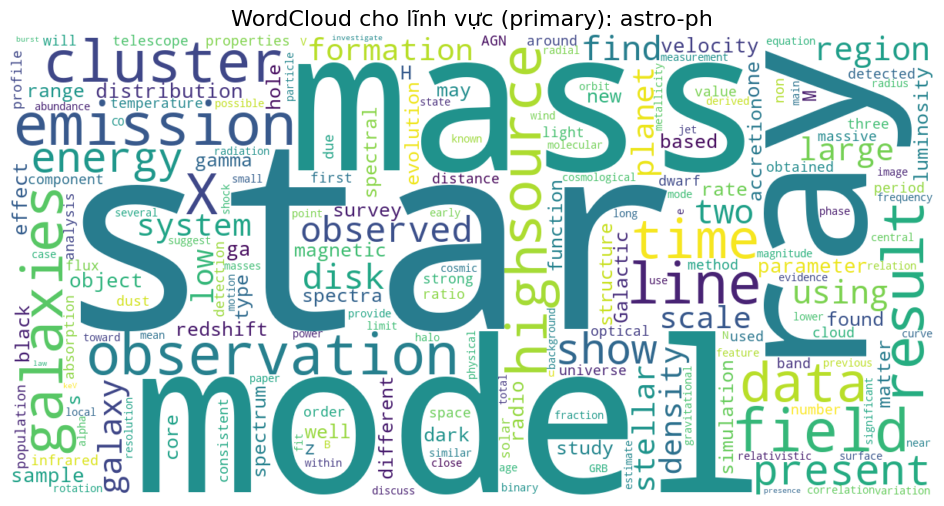

  → Đã lưu: wordclouds\wordcloud_astro-ph.png

🔹 Đang tạo WordCloud cho label chính: cond-mat
  → Lấy được 1000 abstract.


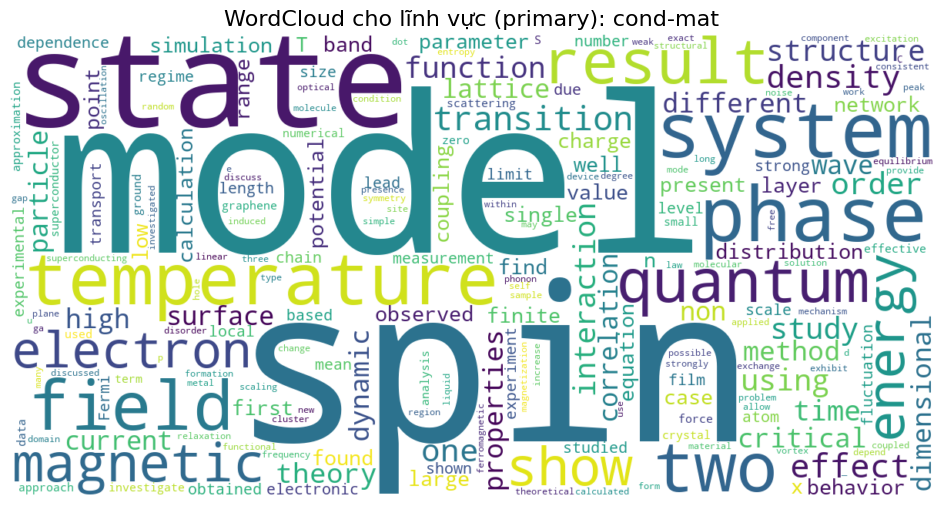

  → Đã lưu: wordclouds\wordcloud_cond-mat.png

🔹 Đang tạo WordCloud cho label chính: cs
  → Lấy được 1000 abstract.


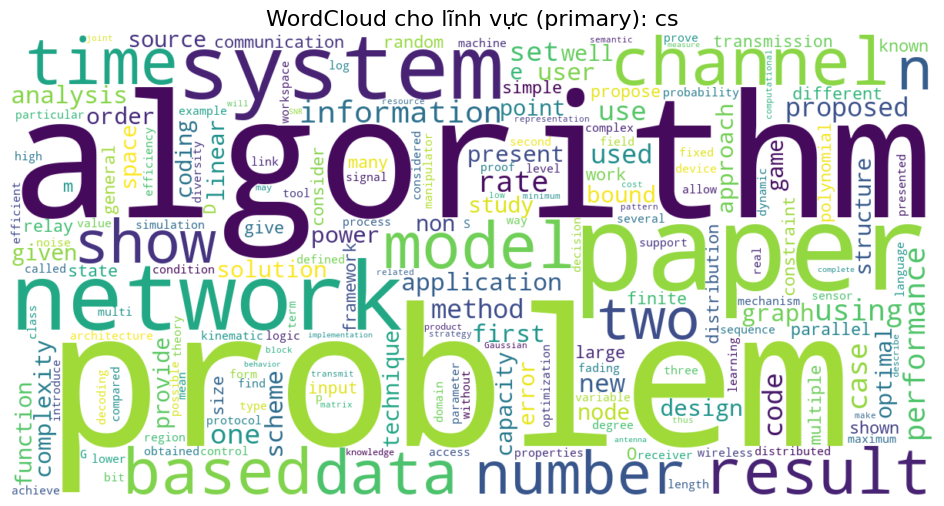

  → Đã lưu: wordclouds\wordcloud_cs.png

🔹 Đang tạo WordCloud cho label chính: math
  → Lấy được 1000 abstract.


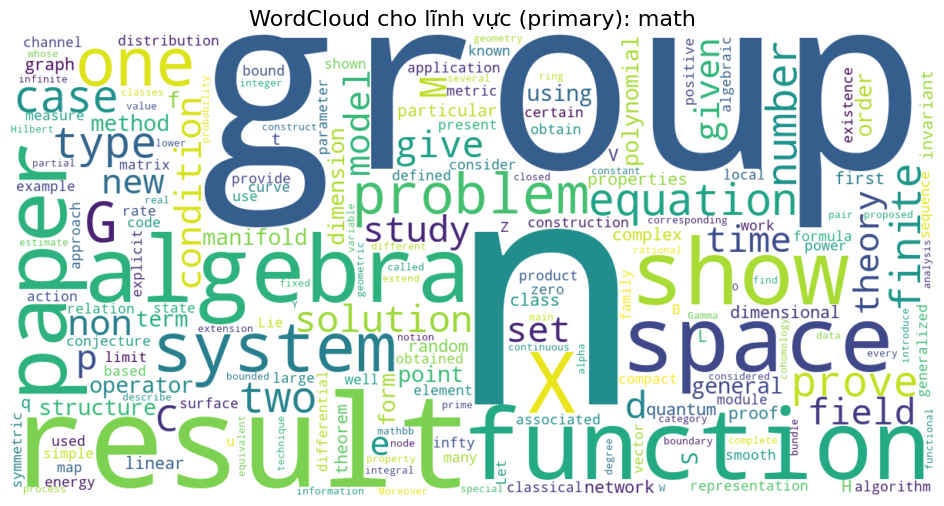

  → Đã lưu: wordclouds\wordcloud_math.png

🔹 Đang tạo WordCloud cho label chính: physics
  → Lấy được 1000 abstract.


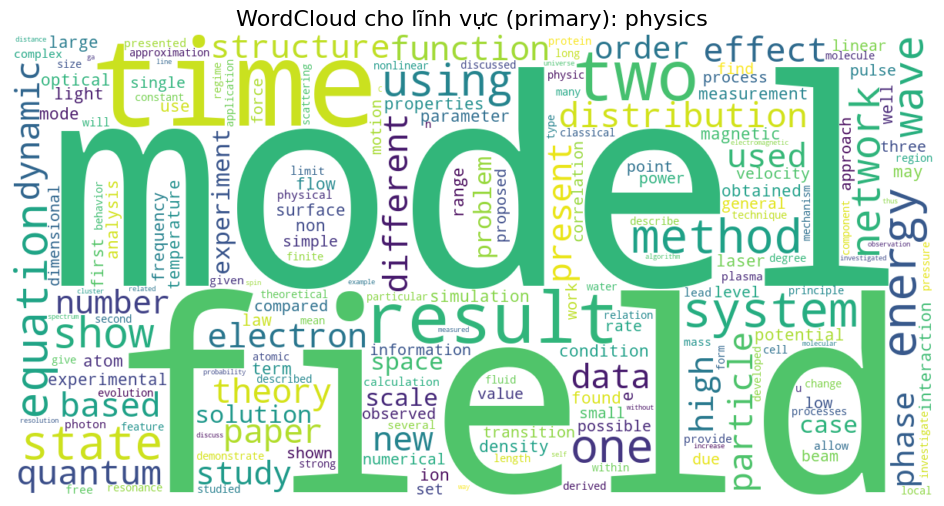

  → Đã lưu: wordclouds\wordcloud_physics.png


In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import os
import random

# ======== Cấu hình ========
major_labels = ['astro-ph', 'cond-mat', 'cs', 'math', 'physics']
SAMPLE_SIZE = 2000    
SAVE_DIR = "wordclouds"  # thư mục lưu ảnh
random.seed(42)

os.makedirs(SAVE_DIR, exist_ok=True)

# ======== Hàm kiểm tra label chính (phần trước dấu '.') ========
def has_primary_label(cat_string, target_label):
    """
    cat_string: ví dụ "cs.LG stat.ML"
    target_label: ví dụ "cs"
    Trả về True nếu một trong các nhãn có primary label == target_label
    """
    if not cat_string:
        return False
    for c in cat_string.split():
        primary = c.split('.')[0].strip().lower()
        if primary == target_label.lower():
            return True
    return False

# ======== Hàm lấy abstract mẫu cho 1 nhãn chính ========
def sample_abstracts_for_primary_label(dataset, label, n=1000):
    abstracts = []
    for example in dataset['train']:
        cats = example.get('categories', '') or ''
        # kiểm tra primary label
        if has_primary_label(cats, label):
            abs_text = example.get('abstract', '')
            if abs_text and abs_text.strip():
                abstracts.append(abs_text)
        if len(abstracts) >= n:
            break
    return abstracts

# ======== Vẽ và lưu WordCloud cho mỗi nhãn ========
for label in major_labels:
    print(f"\n🔹 Đang tạo WordCloud cho label chính: {label}")
    abstracts = sample_abstracts_for_primary_label(ds, label, SAMPLE_SIZE)
    print(f"  → Lấy được {len(abstracts)} abstract.")

    if len(abstracts) == 0:
        print(f"⚠️ Không có dữ liệu cho {label}, bỏ qua.")
        continue

    text = " ".join(abstracts)

    wc = WordCloud(
        width=1200,
        height=600,
        background_color="white",
        max_words=200,
        collocations=False  # tránh ghép cặp từ chung quá nhiều
    ).generate(text)

    plt.figure(figsize=(12,6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud cho lĩnh vực (primary): {label}", fontsize=16)
    plt.show()

    # Lưu ảnh
    out_path = os.path.join(SAVE_DIR, f"wordcloud_{label}.png")
    wc.to_file(out_path)
    print(f"  → Đã lưu: {out_path}")
